# S05 : Reaction Rules as Graph Rewriting (DPO) — Chemistry-first, ITS-native

<div class="alert alert-block alert-info">
<b>SynEdu (S03).</b><br>
This notebook continues S01 (typed molecular graphs & matching) and upgrades from “static graphs” to
<b>transformations</b>: reaction rules, graph rewriting, and chemistry-flavoured examples (Diels–Alder).
</div>

<div class="alert alert-block alert-success">
<b>Aim.</b><br>
Represent a reaction as a <b>rule</b> and apply it to molecules in a way that is:
<ul>
  <li><b>mathematically precise</b> (typed morphisms, DPO rewriting)</li>
  <li><b>chemistry interpretable</b> (bond breaking/forming, conserved atoms)</li>
  <li><b>implementation-ready</b> (RDKit ⇄ NetworkX, atom-mapped reaction SMARTS)</li>
</ul>
</div>

<div class="alert alert-block alert-warning">
<b>Key design decision in S03.</b><br>
For export and comparison we construct an <b>ITS-like change graph</b> <i>directly</i>, then decompose it into
reactant/product graphs. This makes atom correspondence <b>identity-by-node-id</b> (no extra mapping step).
</div>


## Learning outcomes

By the end of this talktorial you can:

1. Write a reaction rule as a **span** \(L \leftarrow K \rightarrow R\) and explain each part chemically.
2. Formally define a **match** \(m: L \hookrightarrow G\) and enumerate all applications in a host molecule.
3. Construct an **ITS graph** \(T\) capturing bond changes (pre/post labels) *without first materializing the product*.
4. Decompose \(T\) back into reactant/product graphs (projection), and export **atom-mapped reaction SMARTS**.
5. Implement a worked Diels–Alder example and inspect **formed/broken/changed** bonds.

## Roadmap

- **0. Setup** (imports, versions, helpers)
- **1. Formalism** (typed graphs, morphisms, DPO rewriting, correctness conditions)
- **2. RDKit ⇄ NetworkX** (typed molecular graphs)
- **3. DPO kernel** (matching + rewrite) and why chemistry needs *wildcards*
- **4. ITS-first rewriting** (construct ITS directly; decompose into reactant/product)
- **5. Export** (atom-mapped reaction SMARTS from ITS)
- **6. Example**: Diels–Alder (butadiene + ethene → cyclohexene)
- **7. Exercises**


In [1]:
# 0. Setup
from __future__ import annotations

import math
from dataclasses import dataclass
from typing import Dict, Hashable, Iterable, List, Tuple, Optional

import networkx as nx
from networkx.algorithms import isomorphism as iso

from rdkit import Chem
from rdkit.Chem import Draw

import rdkit

print("RDKit:", rdkit.__version__)
print("NetworkX:", nx.__version__)

RDKit: 2025.09.3
NetworkX: 3.6.1


## Example molecules used in this notebook

We will use a classic *pericyclic* transformation:

- **Diene**: butadiene (SMILES: `C=CC=C`)
- **Dienophile**: ethene (SMILES: `C=C`)
- Combined as a disconnected reactant mixture: `C=CC=C.C=C`

> Chemistry caveat: this is a toy model (no stereochemistry, no substituents, no endo/exo control).
The point is to demonstrate **bond reorganisation** under a rule-based graph rewriting view.


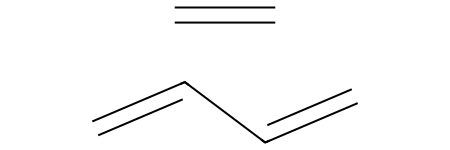

Reactant SMILES (canonical-ish): C=C.C=CC=C


In [2]:
reactant_smiles = "C=CC=C.C=C"
react = Chem.MolFromSmiles(reactant_smiles)
Chem.SanitizeMol(react)

display(react)
print("Reactant SMILES (canonical-ish):", Chem.MolToSmiles(react))

## 1. Formalism: chemistry as typed graph rewriting

### 1.1 Typed molecular graphs (recap from S01)

A (heavy-atom) molecule is a **typed graph**

\[
G = (V_G, E_G, a_G, b_G),
\]

where:

- \(V_G\) = atoms (vertices),
- \(E_G \subseteq \{\{u,v\}\mid u\neq v\}\) = bonds (undirected edges),
- \(a_G: V_G \to \Sigma_V\) = **atom typing** (element, charge, aromaticity, chirality, …),
- \(b_G: E_G \to \Sigma_E\) = **bond typing** (order, aromaticity, ring flag, …).

Chemistry interpretation:
- vertex labels enforce that carbon maps to carbon, etc.
- edge labels enforce that a double bond is not confused with a single bond unless you *allow* it.

### 1.2 Label-preserving morphisms

A **typed graph morphism** \(\varphi: G \to H\) is a function on vertices
\(\varphi_V: V_G \to V_H\) such that:

1. **Atom label preservation**  
\[
a_H(\varphi_V(v)) = a_G(v)\quad \forall v\in V_G.
\]

2. **Adjacency and bond label preservation**  
For every \(\{u,v\}\in E_G\),
\[
\{\varphi_V(u),\varphi_V(v)\}\in E_H
\quad\text{and}\quad
b_H(\{\varphi_V(u),\varphi_V(v)\}) = b_G(\{u,v\}).
\]

In practice we often restrict to **injective** morphisms (embeddings), written
\[
m: G \hookrightarrow H,
\]
which is what NetworkX returns in subgraph matching.

### 1.3 Reaction rules as spans \(L \leftarrow K \rightarrow R\)

A reaction rule is encoded by three typed graphs:

- \(L\) (**left**) — the pattern to be found in a reactant
- \(R\) (**right**) — what replaces it in the product
- \(K\) (**context/interface**) — what is preserved (the “atom identity backbone”)

Formally a DPO rule is a span of morphisms

\[
L \xleftarrow{\ell} K \xrightarrow{r} R,
\]

where \(\ell\) and \(r\) embed \(K\) into \(L\) and \(R\).

Chemistry interpretation:
- \(V_K\) are the atoms that keep their identities through the reaction (the “mapped atoms”).
- \(E_L \setminus E_K\): bonds that must be **broken** (or bond types that must disappear).
- \(E_R \setminus E_K\): bonds that must be **formed**.

A bond **order change** is naturally represented by
- old bond in \(L\) but not in \(K\),
- new bond in \(R\) but not in \(K\),
while the endpoints remain in \(K\).

### 1.4 Where can a rule apply? matches \(m: L \hookrightarrow G\)

Given a reactant molecule graph \(G\), a match is an injective morphism

\[
m: L \hookrightarrow G.
\]

Chemically: “find a substructure in the reactant that looks like the reacting pattern”.

NetworkX’s `GraphMatcher(G, L).subgraph_isomorphisms_iter()` enumerates all such matches.

### 1.5 Correctness conditions you should care about (chemistry view)

DPO rewriting is “correct” when two constraints hold (informally):

1. **Dangling condition** (no half-bonds):  
if you delete an atom (node), you must also delete all incident bonds.  
Chemistry: you cannot leave a bond to a missing atom.

2. **Identification condition** (don’t accidentally merge distinct atoms):  
the match must not identify two different pattern atoms onto the same host atom.  
Chemistry: two atoms in the reacting pattern cannot map to one atom in the molecule.

In this notebook we focus on the common chemistry case: **atom-conserving rules**
(\(V_L = V_K = V_R\)) and only **bond changes**.


### 1.6 The categorical DPO diagram (what “double pushout” means)

In category language, rewriting is defined by two pushouts:

\[
\require{AMScd}
\begin{CD}
K @>{r}>> R \\
@V{\ell}VV @VVV \\
L @>>> D
\end{CD}
\qquad
\begin{CD}
L @>{m}>> G \\
@VVV @VVV \\
D @>>> H
\end{CD}
\]

- The first square constructs the **pushout complement** \(D\): it “removes” \(L\setminus K\) from \(G\) (subject to the dangling condition).
- The second square glues in \(R\setminus K\) to produce the product \(H\).

**Chemistry translation**
- \(K\) are the mapped atoms.
- \(L\setminus K\) are deleted atoms/bonds (leaving groups, bond cleavage).
- \(R\setminus K\) are created atoms/bonds (new substituents, bond formation).

In this notebook we implement the same effect algorithmically (delete-then-add), and additionally
construct an ITS graph that records the pre/post state in one object.


### 1.7 Practical correctness checks (what to verify in code)

When you implement rules in practice, you usually want to validate:

1. **Interface consistency:** \(K\) must embed into both \(L\) and \(R\).  
   (Here we enforce this by using shared node ids for \(K\) inside \(L\) and \(R\).)

2. **Dangling condition (node deletion):** if a host atom is deleted, it must not have bonds to atoms outside the matched subgraph.

3. **Typing consistency:** labels used in `node_match`/`edge_match` must be consistent across RDKit graphs and rule graphs.

We will implement (2) as an optional filter for matches (useful for leaving group rules).


In [3]:
def dangling_ok(G: nx.Graph, rule: Rule, m: Dict[Hashable, Hashable]) -> bool:
    """
    Check the DPO dangling condition for node deletion.

    Let Del = image(L\K) in G. Then for every deleted host node x in Del,
    every incident edge (x,y) in G must have y in image(L).
    """
    L_nodes = set(rule.L.nodes)
    K_nodes = set(rule.K.nodes)
    image_L = set(m.values())
    deleted_host_nodes = {m[ln] for ln in (L_nodes - K_nodes)}

    for x in deleted_host_nodes:
        for y in G.neighbors(x):
            if y not in image_L:
                return False
    return True

## 2. RDKit ⇄ NetworkX: typed molecular graphs

We reuse the S01 “typed molecular graph” representation.

**Node attributes** (atoms):
- `symbol`, `formal_charge`, `aromatic`, `chiral_tag`
- optionally `total_h`

**Edge attributes** (bonds):
- `order` (1/2/3), `aromatic`, `in_ring`

This is enough for most pedagogical examples.


In [4]:
from typing import Dict


def mol_to_graph(mol: Chem.Mol, include_implicit_h: bool = True) -> nx.Graph:
    """
    Convert RDKit Mol -> typed NetworkX graph.

    :param mol: RDKit Mol (assumed sanitized).
    :param include_implicit_h: If True, store total H count per atom as ``total_h``.
    :returns: networkx.Graph with atom/bond labels as node/edge attributes.
    """
    if mol is None:
        raise ValueError("mol is None")

    G = nx.Graph()

    for atom in mol.GetAtoms():
        i = atom.GetIdx()
        attrs: Dict[str, object] = {
            "symbol": atom.GetSymbol(),
            "formal_charge": int(atom.GetFormalCharge()),
            "aromatic": bool(atom.GetIsAromatic()),
            "chiral_tag": str(atom.GetChiralTag()),
        }
        if include_implicit_h:
            attrs["total_h"] = int(atom.GetTotalNumHs())
        G.add_node(i, **attrs)

    for bond in mol.GetBonds():
        u = bond.GetBeginAtomIdx()
        v = bond.GetEndAtomIdx()
        order = int(round(bond.GetBondTypeAsDouble()))
        G.add_edge(
            u,
            v,
            order=order,
            aromatic=bool(bond.GetIsAromatic()),
            in_ring=bool(bond.IsInRing()),
        )

    G.graph["source"] = "rdkit"
    G.graph["rdkit_version"] = rdkit.__version__
    return G


def graph_to_mol(
    G: nx.Graph,
    make_explicit_h: bool = False,
    sanitize: bool = True,
) -> Tuple[Chem.Mol, Dict[Hashable, int]]:
    """
    Reconstruct RDKit Mol from typed NetworkX graph.

    Returns (mol, nx_node -> rdkit_atom_index).

    Notes:
      - Node ids can be any hashable type, but for mapping we prefer ints.
      - Atom ordering is deterministic to keep outputs reproducible.
    """
    rw = Chem.RWMol()
    nx_to_rdk: Dict[Hashable, int] = {}

    # deterministic ordering even if nodes are strings
    nodes_sorted = sorted(
        G.nodes(), key=lambda x: (isinstance(x, int) is False, str(x))
    )

    # atoms
    for node in nodes_sorted:
        n = G.nodes[node]
        atom = Chem.Atom(n.get("symbol", "C"))
        atom.SetFormalCharge(int(n.get("formal_charge", 0)))
        if n.get("aromatic", False):
            atom.SetIsAromatic(True)

        ch_tag = n.get("chiral_tag")
        if ch_tag and ch_tag != "CHI_UNSPECIFIED":
            try:
                atom.SetChiralTag(getattr(Chem.rdchem.ChiralType, ch_tag))
            except Exception:
                pass  # best-effort only

        nx_to_rdk[node] = rw.AddAtom(atom)

    # bonds
    for u, v, e in G.edges(data=True):
        order = int(e.get("order", 1))
        btype = {
            1: Chem.rdchem.BondType.SINGLE,
            2: Chem.rdchem.BondType.DOUBLE,
            3: Chem.rdchem.BondType.TRIPLE,
        }.get(order, Chem.rdchem.BondType.SINGLE)
        rw.AddBond(nx_to_rdk[u], nx_to_rdk[v], btype)

    mol = rw.GetMol()

    # optional explicit H
    if make_explicit_h:
        em = Chem.RWMol(mol)
        for node, rdk_idx in nx_to_rdk.items():
            total_h = G.nodes[node].get("total_h")
            if total_h is None:
                continue
            atom = em.GetAtomWithIdx(rdk_idx)
            current_h = sum(1 for nb in atom.GetNeighbors() if nb.GetSymbol() == "H")
            for _ in range(max(int(total_h) - current_h, 0)):
                h_idx = em.AddAtom(Chem.Atom("H"))
                em.AddBond(rdk_idx, h_idx, Chem.rdchem.BondType.SINGLE)
        mol = em.GetMol()

    if sanitize:
        Chem.SanitizeMol(mol)
    return mol, nx_to_rdk

In [5]:
G_react = mol_to_graph(react, include_implicit_h=False)
print("Nodes:", G_react.number_of_nodes(), "Edges:", G_react.number_of_edges())
list(G_react.nodes(data=True))[:3], list(G_react.edges(data=True))[:3]

Nodes: 6 Edges: 4


([(0,
   {'symbol': 'C',
    'formal_charge': 0,
    'aromatic': False,
    'chiral_tag': 'CHI_UNSPECIFIED'}),
  (1,
   {'symbol': 'C',
    'formal_charge': 0,
    'aromatic': False,
    'chiral_tag': 'CHI_UNSPECIFIED'}),
  (2,
   {'symbol': 'C',
    'formal_charge': 0,
    'aromatic': False,
    'chiral_tag': 'CHI_UNSPECIFIED'})],
 [(0, 1, {'order': 2, 'aromatic': False, 'in_ring': False}),
  (1, 2, {'order': 1, 'aromatic': False, 'in_ring': False}),
  (2, 3, {'order': 2, 'aromatic': False, 'in_ring': False})])

## 3. DPO rewriting kernel (chemistry-friendly)

### 3.1 Why chemistry rules need wildcards

A “reaction rule” almost never wants to pin down *every* atom attribute.
Examples:
- a Diels–Alder rule wants “carbon, non-aromatic”, but usually not fixed `chiral_tag`.
- generic rules often allow any `formal_charge` on spectator atoms.
- aromaticity handling depends on the representation (Kekulé vs aromatic bonds).

So we use **pattern-side wildcards**:
- if an attribute is missing in the pattern, we ignore it;
- if present but `None`, we also ignore it;
- otherwise we require equality.

This corresponds to defining a compatibility predicate
\(\Phi_V(d_G, d_L)\) and \(\Phi_E(d_G, d_L)\).


In [6]:
def wildcard_node_match(keys: Iterable[str]):
    keys = tuple(keys)

    def _match(d_host: Dict, d_pat: Dict) -> bool:
        for k in keys:
            if k not in d_pat:
                continue
            pv = d_pat.get(k)
            if pv is None:
                continue
            if d_host.get(k) != pv:
                return False
        return True

    return _match


def wildcard_edge_match(keys: Iterable[str]):
    keys = tuple(keys)

    def _match(e_host: Dict, e_pat: Dict) -> bool:
        for k in keys:
            if k not in e_pat:
                continue
            pv = e_pat.get(k)
            if pv is None:
                continue
            if e_host.get(k) != pv:
                return False
        return True

    return _match


@dataclass(frozen=True)
class Rule:
    """DPO rule L <- K -> R."""

    L: nx.Graph
    K: nx.Graph
    R: nx.Graph
    name: str = "rule"

### 3.2 Matches in NetworkX: beware mapping direction

If you build:

```python
GM = GraphMatcher(G, L)
```

then `subgraph_isomorphisms_iter()` yields dictionaries mapping

\[
V(G)\to V(L)
\]

i.e. **host node → pattern node**.

For rewriting we want **pattern node → host node**, so we invert each mapping.


## 4. ITS-first rewriting (DPO-like)

### 4.1 What is an ITS graph here?

We define an ITS-like graph \(T\) that stores **both** pre- and post- bond types
on the *same atom identities*.

- Nodes represent atom identities (plus possibly created/deleted atoms).
- Each edge carries a pair:
  \[
  (b_{\text{pre}}, b_{\text{post}}),
  \]
  where \(b=0\) means “no bond”.

Chemistry reading:
- formed bond: \(0 \to 1\) (or \(0\to 2\))
- broken bond: \(1 \to 0\) (or \(2\to 0\))
- order change: \(1 \to 2\) etc.

### 4.2 Why construct ITS directly?

If you construct a product graph first, you must still maintain an atom mapping.
In DPO, the “identity backbone” is precisely \(K\), so the natural carrier object is:

> **the change graph** on conserved identities, plus any created/deleted identities.

By building ITS directly, the mapping is trivial:
- reactant atom \(v\) maps to product atom \(v\) **by node id**.

This makes export to atom-mapped SMARTS clean and deterministic.


In [20]:
def _u_edge(u, v):
    return (u, v) if u <= v else (v, u)


def dpo_match_iter(
    G: nx.Graph,
    L: nx.Graph,
    node_keys: Iterable[str] = ("symbol", "formal_charge", "aromatic"),
    edge_keys: Iterable[str] = ("order", "aromatic"),
):
    """Yield mappings m: V(L) -> V(G)."""
    nm = wildcard_node_match(node_keys)
    em = wildcard_edge_match(edge_keys)
    GM = iso.GraphMatcher(G, L, node_match=nm, edge_match=em)

    for m_GL in GM.subgraph_isomorphisms_iter():  # G -> L
        m = {l: g for g, l in m_GL.items()}  # L -> G
        yield m


def dpo_application_to_its(
    G: nx.Graph,
    rule: Rule,
    m: Dict[Hashable, Hashable],
    node_attr_keys: Iterable[str] = (
        "symbol",
        "formal_charge",
        "aromatic",
        "chiral_tag",
    ),
    edge_attr_keys: Iterable[str] = ("order", "aromatic"),
) -> nx.Graph:
    """
    Construct an ITS-like graph T directly from (G, rule, match m).

    - Node ids for conserved atoms are the same as in host graph G.
    - New atoms (R\K) get fresh integer ids > max(G).
    - Deleted atoms (L\K) remain as nodes in T with present_post=False.

    Edge attrs in T:
      - pre_order, post_order
      - pre_aromatic, post_aromatic
    """
    L, K, R = rule.L, rule.K, rule.R
    L_nodes, K_nodes = set(L.nodes), set(K.nodes)

    # ---- determine deleted host atoms (L\K) ----
    deleted_host_nodes = {m[ln] for ln in (L_nodes - K_nodes)}

    # ---- allocate fresh ids for created atoms (R\K) ----
    host_int_nodes = [n for n in G.nodes if isinstance(n, int)]
    next_id = (max(host_int_nodes) + 1) if host_int_nodes else 0
    fresh: Dict[Hashable, int] = {}

    for rn in R.nodes:
        if rn in K_nodes:
            continue
        fresh[rn] = next_id
        next_id += 1

    # ---- helper: map rule node -> ITS node id ----
    def its_node_id(rn: Hashable) -> Hashable:
        if rn in K_nodes:
            return m[rn]
        return fresh[rn]

    # ---- pre-state edge labels (from G) ----
    pre_edges: Dict[Tuple[Hashable, Hashable], Dict[str, object]] = {}
    for u, v, d in G.edges(data=True):
        pre_edges[_u_edge(u, v)] = {k: d.get(k) for k in edge_attr_keys}

    # ---- post-state starts as pre-state ----
    post_edges = dict(pre_edges)

    # removing nodes implies removing incident edges in post
    for u, v in list(post_edges.keys()):
        if u in deleted_host_nodes or v in deleted_host_nodes:
            post_edges.pop((u, v), None)

    # ---- delete edges specified by L\K ----
    K_edges = {_u_edge(u, v) for (u, v) in K.edges}
    for u, v in L.edges:
        if _u_edge(u, v) in K_edges:
            continue
        hu, hv = m[u], m[v]
        post_edges.pop(_u_edge(hu, hv), None)

    # ---- add/overwrite edges from R ----
    for u, v, d in R.edges(data=True):
        hu, hv = its_node_id(u), its_node_id(v)
        post_edges[_u_edge(hu, hv)] = {k: d.get(k) for k in edge_attr_keys}

    # ---- build ITS T ----
    T = nx.Graph()
    # nodes: all host nodes + created nodes
    for n, d in G.nodes(data=True):
        attrs = {k: d.get(k) for k in node_attr_keys}
        attrs["present_pre"] = True
        attrs["present_post"] = n not in deleted_host_nodes
        T.add_node(n, **attrs)

    for rn, nid in fresh.items():
        d = R.nodes[rn]
        attrs = {k: d.get(k) for k in node_attr_keys}
        attrs["present_pre"] = False
        attrs["present_post"] = True
        T.add_node(nid, **attrs)

    # edges: union of pre and post edge sets
    all_edges = set(pre_edges.keys()) | set(post_edges.keys())
    for u, v in sorted(all_edges):
        pre = pre_edges.get((u, v), {})
        post = post_edges.get((u, v), {})
        T.add_edge(
            u,
            v,
            pre_order=int(pre.get("order", 0) or 0),
            post_order=int(post.get("order", 0) or 0),
            pre_aromatic=bool(pre.get("aromatic", False) or False),
            post_aromatic=bool(post.get("aromatic", False) or False),
        )

    T.graph["rule"] = rule.name
    return T


def its_to_reactant_graph(T: nx.Graph) -> nx.Graph:
    """
    Project ITS graph to reactant molecular graph.

    Rule:
      keep edge (u,v) iff pre_order is not None
    """
    G = nx.Graph()

    # nodes
    for n, d in T.nodes(data=True):
        if d.get("present_pre", True):
            G.add_node(
                n,
                symbol=d.get("symbol"),
                formal_charge=d.get("formal_charge", 0),
                aromatic=d.get("aromatic", False),
            )

    # edges
    for u, v, d in T.edges(data=True):
        if u not in G.nodes or v not in G.nodes:
            continue

        pre = d.get("pre_order")
        if pre is not None:
            G.add_edge(
                u,
                v,
                order=int(pre),
                aromatic=bool(d.get("pre_aromatic", False)),
            )

    return G


def its_to_product_graph(T: nx.Graph) -> nx.Graph:
    """
    Project ITS graph to product molecular graph.

    Rule:
      keep edge (u,v) iff post_order is not None
    """
    G = nx.Graph()

    # nodes
    for n, d in T.nodes(data=True):
        if d.get("present_post", True):
            G.add_node(
                n,
                symbol=d.get("symbol"),
                formal_charge=d.get("formal_charge", 0),
                aromatic=d.get("aromatic", False),
            )

    # edges
    for u, v, d in T.edges(data=True):
        if u not in G.nodes or v not in G.nodes:
            continue

        post = d.get("post_order")
        if post is not None:
            G.add_edge(
                u,
                v,
                order=int(post),
                aromatic=bool(d.get("post_aromatic", False)),
            )

    return G

In [14]:
def apply_rule_to_its(
    reactant_graph: nx.Graph,
    rule: Rule,
    node_keys=("symbol", "formal_charge", "aromatic", "present_pre", "present_post"),
    edge_keys=("pre_order", "post_order", "pre_aromatic", "post_aromatic"),
    deduplicate: bool = True,
    strict_dangling: bool = True,
) -> list[nx.Graph]:
    """
    Apply a DPO rule by constructing ITS graphs directly.

    Returns:
        List of ITS graphs T where node identity = atom mapping.
    """

    Ts = []

    nm = wildcard_node_match(node_keys)
    em = wildcard_edge_match(edge_keys)

    GM = iso.GraphMatcher(reactant_graph, rule.L, node_match=nm, edge_match=em)

    for m_GL in GM.subgraph_isomorphisms_iter():
        # invert mapping: L -> G
        m = {l: g for g, l in m_GL.items()}

        # -------------------------------
        # Construct ITS graph T
        # -------------------------------
        T = nx.Graph()

        # ---- nodes ----
        for n, d in reactant_graph.nodes(data=True):
            T.add_node(n, **d, present_pre=True, present_post=True)

        # ---- edges: start from reactant ----
        for u, v, d in reactant_graph.edges(data=True):
            T.add_edge(
                u,
                v,
                pre_order=d.get("order"),
                post_order=d.get("order"),
                pre_aromatic=d.get("aromatic", False),
                post_aromatic=d.get("aromatic", False),
            )

        # ---- delete L\K edges ----
        for u, v in rule.L.edges:
            if not rule.K.has_edge(u, v):
                hu, hv = m[u], m[v]
                if T.has_edge(hu, hv):
                    T.edges[hu, hv]["post_order"] = None
                    T.edges[hu, hv]["post_aromatic"] = None

        # ---- add R\K edges ----
        for u, v, d in rule.R.edges(data=True):
            if not rule.K.has_edge(u, v):
                hu, hv = m[u], m[v]
                if not T.has_edge(hu, hv):
                    T.add_edge(
                        hu,
                        hv,
                        pre_order=None,
                        pre_aromatic=None,
                        post_order=d.get("order"),
                        post_aromatic=d.get("aromatic", False),
                    )
                else:
                    T.edges[hu, hv]["post_order"] = d.get("order")
                    T.edges[hu, hv]["post_aromatic"] = d.get("aromatic", False)

        Ts.append(T)

    if not deduplicate:
        return Ts

    uniq: list[nx.Graph] = []
    for T in Ts:
        if not any(nx.is_isomorphic(U, T, node_match=nm, edge_match=em) for U in uniq):
            uniq.append(T)

    return uniq

## 5. Export: atom-mapped reaction SMARTS (ITS-native)

### 5.1 DPO-like “identity = node id”

Because we build ITS \(T\) on conserved identities, a node \(v\) refers to:

- the same atom in the reactant graph \(\pi_{\text{pre}}(T)\),
- the same atom in the product graph \(\pi_{\text{post}}(T)\),

whenever \(v\) is present in both (`present_pre=True` and `present_post=True`).

So atom mapping becomes **identity-by-node-id**:
\[
\text{map}(v) := v+1.
\]

New atoms (if created) naturally get fresh ids \(> \max(V_G)\), therefore also fresh map numbers.

### 5.2 Implementation

We:
1. project ITS → reactant graph \(G\) and product graph \(H\),
2. convert each graph to RDKit Mol,
3. set atom maps by graph node id,
4. export `MolToSmarts(reactant)>>MolToSmarts(product)`.

This avoids any post-hoc “mapping inference”.


### 5.3 Practical detail: RDKit atom reordering vs. mapping stability

RDKit may reorder atoms internally during sanitization or SMILES/SMARTS generation.
That is **not a problem** as long as:

- each atom carries its `AtomMapNum`,
- the same identity uses the same map number on both sides.

Because we set `map = node_id + 1` after converting from graphs, the mapping remains stable even if RDKit
chooses a different atom ordering for the final SMARTS string.


In [21]:
def graph_to_mapped_smarts(G: nx.Graph) -> Tuple[Chem.Mol, str]:
    """Convert graph -> RDKit Mol and return (mol, mapped_smarts) using map=v+1."""
    mol, nx_to_rdk = graph_to_mol(G, sanitize=True)
    m = Chem.Mol(mol)
    for nx_node, rdk_idx in nx_to_rdk.items():
        if not isinstance(nx_node, int):
            raise TypeError("For identity mapping we expect integer node ids.")
        m.GetAtomWithIdx(rdk_idx).SetAtomMapNum(int(nx_node) + 1)
    return m, Chem.MolToSmarts(m)


def reaction_smarts_from_its(T: nx.Graph):
    Gre = its_to_reactant_graph(T)
    Gpr = its_to_product_graph(T)

    r_mol, r_map = graph_to_mol(Gre)
    p_mol, p_map = graph_to_mol(Gpr)

    # atom map number = node id + 1
    for a in r_mol.GetAtoms():
        a.SetAtomMapNum(a.GetIdx() + 1)
    for a in p_mol.GetAtoms():
        a.SetAtomMapNum(a.GetIdx() + 1)

    smarts = f"{Chem.MolToSmarts(r_mol)}>>{Chem.MolToSmarts(p_mol)}"
    return r_mol, p_mol, smarts

## 6. Worked example: Diels–Alder as a DPO rule

### 6.1 Chemistry view

Diels–Alder (4+2 cycloaddition) is a **concerted** pericyclic reaction:

- two \(\pi\) bonds disappear,
- two new \(\sigma\) bonds appear,
- one \(\pi\) bond remains in the cyclohexene product.

We encode this as a bond-rewriting rule that conserves all 6 carbon atoms:

- \(V_L = V_K = V_R\) (atom-conserving)
- only edges/bond orders change

This is the “cleanest” DPO case, and ideal for educational purposes.


In [22]:
def diels_alder_rule_minimal() -> Rule:
    """
    Minimal Diels–Alder:
      butadiene + ethene -> cyclohexene (one C=C remains).

    Pattern nodes are labelled as generic carbon atoms.
    We match only on:
      - atom: symbol/formal_charge/aromatic
      - bond: order/aromatic
    """

    def C():
        return {
            "symbol": "C",
            "formal_charge": 0,
            "aromatic": False,
            "chiral_tag": "CHI_UNSPECIFIED",
        }

    def sb():
        return {"order": 1, "aromatic": False}

    def db():
        return {"order": 2, "aromatic": False}

    # L: reacting pi system
    L = nx.Graph()
    for x in "abcdef":
        L.add_node(x, **C())

    # diene a=b - c=d
    L.add_edge("a", "b", **db())
    L.add_edge("b", "c", **sb())
    L.add_edge("c", "d", **db())

    # dienophile e=f
    L.add_edge("e", "f", **db())

    # K: conserved atoms only
    K = nx.Graph()
    for x in "abcdef":
        K.add_node(x, **C())

    # R: cyclohexene ring; choose remaining double bond b=c
    R = nx.Graph()
    for x in "abcdef":
        R.add_node(x, **C())

    R.add_edge("a", "b", **sb())
    R.add_edge("b", "c", **db())  # remaining double bond
    R.add_edge("c", "d", **sb())
    R.add_edge("d", "e", **sb())  # newly formed
    R.add_edge("e", "f", **sb())
    R.add_edge("f", "a", **sb())  # newly formed

    return Rule(L=L, K=K, R=R, name="Diels_Alder_minimal")


rule_da = diels_alder_rule_minimal()
print(
    rule_da.name,
    "| L nodes:",
    rule_da.L.number_of_nodes(),
    "L edges:",
    rule_da.L.number_of_edges(),
)

Diels_Alder_minimal | L nodes: 6 L edges: 4


### 6.2 Apply rule → ITS → (reactant, product) → mapped SMARTS

We:
- convert RDKit reactant mixture to a typed graph \(G\),
- apply the rule to get ITS graphs \(T\),
- decompose the first ITS to reactant/product,
- export mapped reaction SMARTS.


Number of ITS applications: 1
Atom-mapped reaction SMARTS:
[#6:1]=[#6:2]-[#6:3]=[#6:4].[#6:5]=[#6:6]>>[#6:1]1-[#6:2]=[#6:3]-[#6:4]-[#6:5]-[#6:6]-1


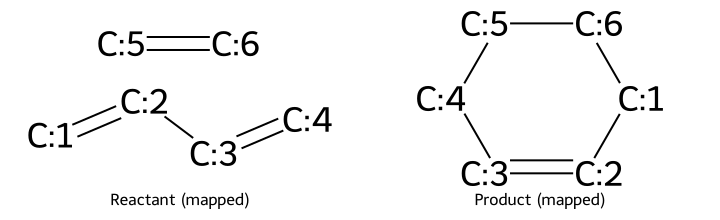

In [23]:
G = mol_to_graph(react, include_implicit_h=False)
Ts = apply_rule_to_its(G, rule_da, deduplicate=True)

print("Number of ITS applications:", len(Ts))

T0 = Ts[0]
r_mapped, p_mapped, rxn_smarts = reaction_smarts_from_its(T0)

print("Atom-mapped reaction SMARTS:")
print(rxn_smarts)

display(
    Draw.MolsToGridImage(
        [r_mapped, p_mapped],
        legends=["Reactant (mapped)", "Product (mapped)"],
        molsPerRow=2,
        subImgSize=(360, 220),
    )
)

**Sanity check:** Diels–Alder is atom-conserving (no node deletion), so the dangling condition is trivially satisfied.
For leaving-group rules, `strict_dangling=True` helps prevent chemically nonsensical deletions that cut bonds outside the matched substructure.

In [24]:
# dangling check on the first match (should be True here)
m0 = next(dpo_match_iter(G, rule_da.L))
print("Dangling ok?", dangling_ok(G, rule_da, m0))

Dangling ok? True


### 6.3 Inspect the ITS: formed / broken / changed bonds

For each ITS edge \(uv\), we look at \((\text{pre\_order}, \text{post\_order})\).

- formed: \(0 \to >0\)
- broken: \(>0 \to 0\)
- order change: \(>0 \to >0\) but different


In [26]:
rows = []

for u, v, d in T0.edges(data=True):
    pre = d.get("pre_order")
    post = d.get("post_order")

    # unchanged bond → skip
    if pre == post:
        continue

    if pre is None and post is not None:
        change = "bond formed"
    elif pre is not None and post is None:
        change = "bond broken"
    elif pre is not None and post is not None:
        change = f"bond order change {pre}→{post}"
    else:
        # both None should never happen in a well-formed ITS
        continue

    rows.append(
        {
            "u": u,
            "v": v,
            "pre_order": pre,
            "post_order": post,
            "change": change,
        }
    )

import pandas as pd

pd.DataFrame(rows)

,u,v,pre_order,post_order,change
0,0,1,2.0,1,bond order change 2→1
1,0,5,NaN,1,bond formed
2,1,2,1.0,2,bond order change 1→2
3,2,3,2.0,1,bond order change 2→1
4,3,4,NaN,1,bond formed
5,4,5,2.0,1,bond order change 2→1


### 6.3b A compact ITS “transition fingerprint”

A very lightweight mapping-free reaction descriptor is the multiset of bond transitions:

\[
\{(b_{\text{pre}}, b_{\text{post}})\}_{uv\in E(T)}.
\]

For example:
- many \(2\to 1\) transitions indicate \(\pi\)-bonds turning into \(\sigma\)-bonds,
- \(0\to 1\) counts are bond formations,
- \(1\to 0\) counts are bond breakages.

This is not as expressive as full ITS isomorphism, but it is cheap and often useful for clustering/filtering.


In [27]:
from collections import Counter

transitions = Counter(
    (d["pre_order"], d["post_order"]) for _, _, d in T0.edges(data=True)
)
transitions

Counter({(2, 1): 3, (None, 1): 2, (1, 2): 1})

Chemistry check (Diels–Alder expectation):

- **broken**: the dienophile double bond \(e=f\) becomes single (often represented as an order change),
  and one diene double bond changes.
- **formed**: two new C–C \(\sigma\) bonds close the ring.

Because our minimal rule encodes “remove old double bonds, add new single bonds”, you should see:
- two **formed** edges,
- and **order_change** edges accounting for \(\pi\to\sigma\) shifts.


### 6.4 Verify projections: ITS → reactant graph and product graph

We can reconstruct RDKit molecules from the projected graphs and compare SMILES.


Reactant (projected) SMILES: C=C.C=CC=C
Product  (projected) SMILES: C1=CCCCC1


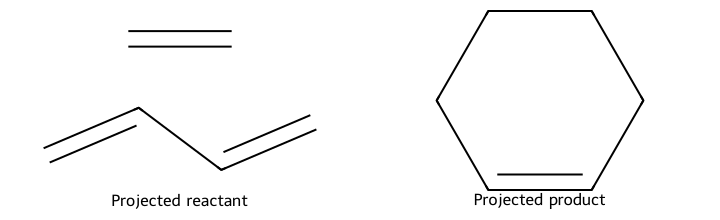

In [28]:
Gre = its_to_reactant_graph(T0)
Gpr = its_to_product_graph(T0)

mol_re, _ = graph_to_mol(Gre, sanitize=True)
mol_pr, _ = graph_to_mol(Gpr, sanitize=True)

print("Reactant (projected) SMILES:", Chem.MolToSmiles(mol_re))
print("Product  (projected) SMILES:", Chem.MolToSmiles(mol_pr))

display(
    Draw.MolsToGridImage(
        [mol_re, mol_pr],
        legends=["Projected reactant", "Projected product"],
        molsPerRow=2,
        subImgSize=(360, 220),
    )
)

## 7. Technical notes (what you will want in real chemistry pipelines)

### 7.1 Aromaticity and Kekulé form
RDKit may represent aromatic systems with aromatic bonds (`BondType.AROMATIC`) or Kekulé double/single.
A rule library must decide on one representation:
- either match on `aromatic=True` bonds/nodes,
- or kekulize all molecules before rewriting.

### 7.2 Stereochemistry (endo/exo, R/S)
Pericyclic reactions have stereochemical outcomes. Encoding this requires:
- stereo atom attributes (chiral tags),
- double bond stereo (E/Z),
- and rule-side constraints (not just plain graph rewriting).

### 7.3 Atom addition/deletion (leaving groups, proton transfers)
Many reactions are not atom-conserving in the heavy-atom graph, especially if you omit spectators.
The ITS design here supports this via:
- `present_pre`, `present_post` on nodes,
- `pre_order=0` or `post_order=0` on edges.

### 7.4 Multiple matches and automorphisms
Symmetric patterns lead to multiple subgraph isomorphisms.
For chemistry, you often want **unique products**:
- we deduplicate ITS graphs by isomorphism on `(pre,post)` edge labels.


## 8. Exercises

Try these without changing the core kernels.

### Exercise 1 — Diels–Alder variants
Change the Diels–Alder rule so that the remaining double bond is **a–b** instead of **b–c**.
- How do the ITS “order_change” edges differ?
- Does RDKit sanitize the product?

### Exercise 2 — Add a wildcard
Modify matching keys so that the rule matches carbon atoms regardless of `formal_charge`.
(Hint: omit `formal_charge` from `node_keys`.)

### Exercise 3 — Build a tiny rule for “halogen substitution”
Encode a rule that replaces `C–Cl` with `C–O` (as in your earlier example) and export mapped SMARTS via ITS.
- Verify the mapping is identity-by-node-id for conserved atoms.


<details>
<summary><b>Solutions (sketch)</b></summary>

**Ex1.** In `diels_alder_rule_minimal`, change which edge in `R` is double.
You must also ensure the corresponding edges in `L` that should disappear are present (and not in `K`).

**Ex2.** Call:

```python
Ts = apply_rule_to_its(G, rule_da, node_keys=("symbol","aromatic"), edge_keys=("order","aromatic"))
```

**Ex3.** Use \(K\) with the carbon node only; in ITS, carbon keeps its node id so map numbers are consistent.

</details>
